In [5]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
def load_subject_data(subject_id):
    file_path = f'WESAD/S{subject_id}/S{subject_id}.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    return data

# Пример использования
subject_data = load_subject_data(2)

# Структура данных
print("Ключи данных:", subject_data.keys())
# dict_keys(['signal', 'label', 'subject'])

Ключи данных: dict_keys(['signal', 'label', 'subject'])


In [12]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных субъекта
def load_subject_data(subject_id):
    """Загружает данные указанного субъекта"""
    file_path = f'WESAD/S{subject_id}/S{subject_id}.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    return data

# Загрузка данных субъекта 2
subject_id = 2
data = load_subject_data(subject_id)

# Обзор структуры данных
print("="*60)
print(f"WESAD Dataset - Субъект S{subject_id}")
print("="*60)

print("\n1. Основные ключи данных:")
print(f"   {list(data.keys())}")

print("\n2. Информация о субъекте:")
if isinstance(data['subject'], dict):
    for key, value in data['subject'].items():
        print(f"   {key}: {value}")
else:
    print(f"   ID: {data['subject']}")

print("\n3. Доступные сигналы с chest (грудной датчик):")
chest_signals = data['signal']['chest'].keys()
for signal_name in chest_signals:
    signal_data = data['signal']['chest'][signal_name]
    print(f"   {signal_name:6s}: shape = {signal_data.shape}")

print("\n4. Доступные сигналы с wrist (наручный датчик):")
wrist_signals = data['signal']['wrist'].keys()
for signal_name in wrist_signals:
    signal_data = data['signal']['wrist'][signal_name]
    print(f"   {signal_name:6s}: shape = {signal_data.shape}")

print("\n5. Метки (labels):")
labels = data['label']
print(f"   Shape: {labels.shape}")
print(f"   Уникальные значения: {np.unique(labels)}")

# Подсчёт времени в каждом состоянии
label_names = {
    0: 'Not defined',
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation'
}

print("\n6. Распределение состояний (в семплах):")
for label_val in np.unique(labels):
    label_val_int = int(label_val)
    count = np.sum(labels == label_val)
    percentage = (count / len(labels)) * 100
    print(f"   {label_val_int} - {label_names.get(label_val_int, 'Unknown'):12s}: {count:8d} ({percentage:.1f}%)")

print("\n" + "="*60)
print("Данные успешно загружены!")
print("="*60)

WESAD Dataset - Субъект S2

1. Основные ключи данных:
   ['signal', 'label', 'subject']

2. Информация о субъекте:
   ID: S2

3. Доступные сигналы с chest (грудной датчик):
   ACC   : shape = (4255300, 3)
   ECG   : shape = (4255300, 1)
   EMG   : shape = (4255300, 1)
   EDA   : shape = (4255300, 1)
   Temp  : shape = (4255300, 1)
   Resp  : shape = (4255300, 1)

4. Доступные сигналы с wrist (наручный датчик):
   ACC   : shape = (194528, 3)
   BVP   : shape = (389056, 1)
   EDA   : shape = (24316, 1)
   TEMP  : shape = (24316, 1)

5. Метки (labels):
   Shape: (4255300,)
   Уникальные значения: [0 1 2 3 4 6 7]

6. Распределение состояний (в семплах):
   0 - Not defined :  2142701 (50.4%)
   1 - Baseline    :   800800 (18.8%)
   2 - Stress      :   430500 (10.1%)
   3 - Amusement   :   253400 (6.0%)
   4 - Meditation  :   537599 (12.6%)
   6 - Unknown     :    45500 (1.1%)
   7 - Unknown     :    44800 (1.1%)

Данные успешно загружены!


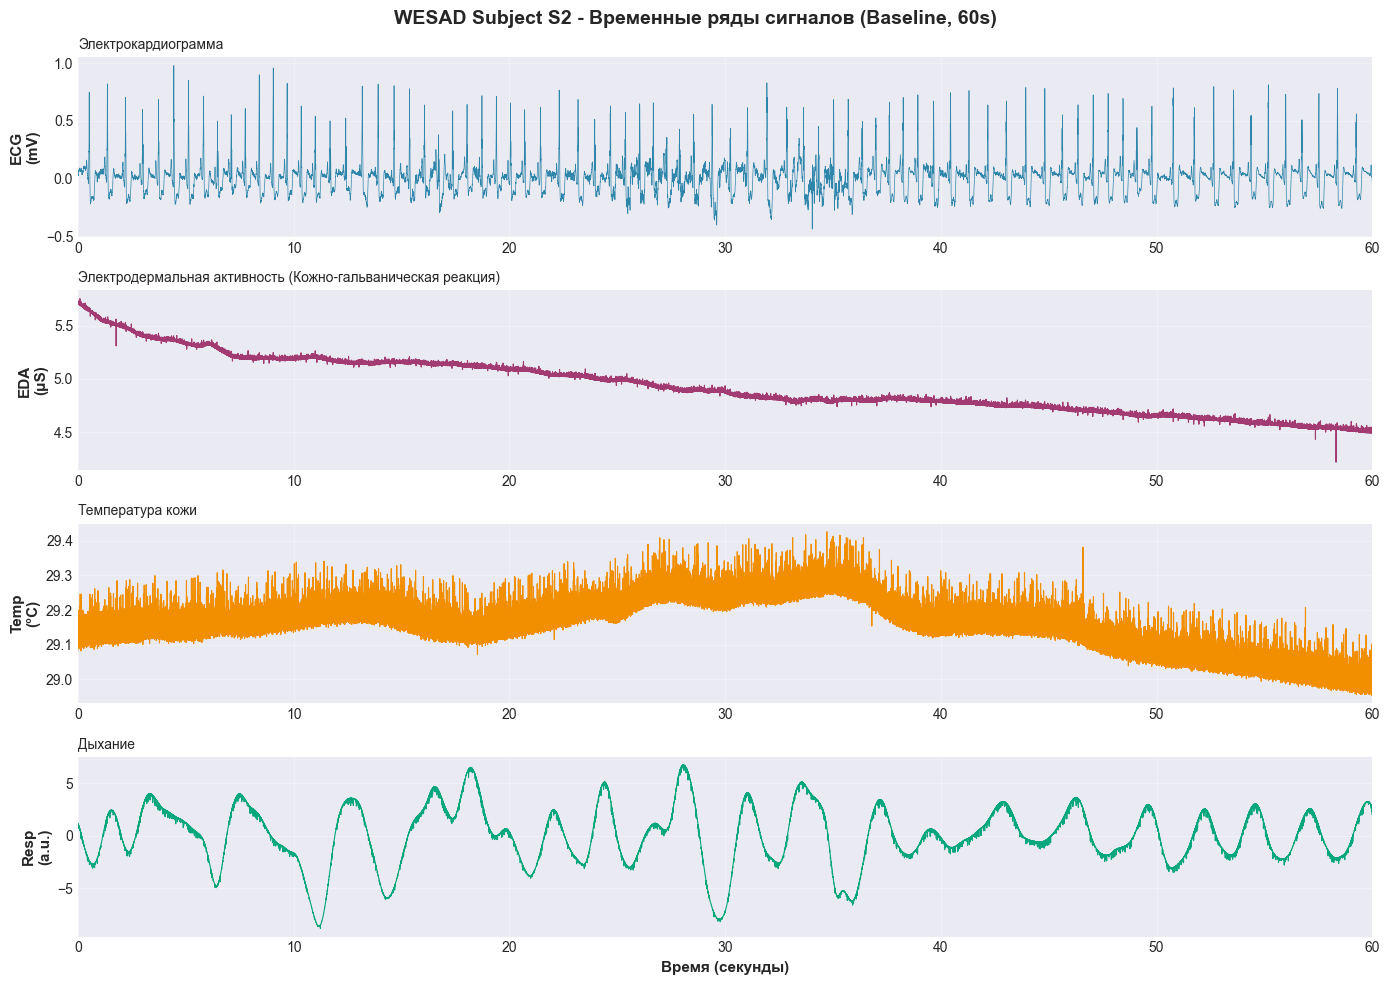

Статистика сигналов (первые 60 секунд Baseline)
ECG  - Min: -0.4359, Max: 0.9793, Mean: 0.0019, Std: 0.1395
EDA  - Min: 4.2156, Max: 5.7568, Mean: 4.9315, Std: 0.2716
Temp - Min: 28.9543, Max: 29.4262, Mean: 29.1566, Std: 0.0753
Resp - Min: -8.8058, Max: 6.7429, Mean: 0.0798, Std: 2.8228


In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
def load_subject_data(subject_id):
    file_path = f'WESAD/S{subject_id}/S{subject_id}.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    return data

# Загрузка данных субъекта
subject_id = 2
data = load_subject_data(subject_id)

# Извлечение сигналов с chest датчика
chest = data['signal']['chest']
labels = data['label']

# Параметры
sampling_rate = 700  # Hz для chest датчика
duration_to_plot = 60  # секунд для визуализации
samples_to_plot = sampling_rate * duration_to_plot

# Выбираем начало baseline периода (label == 1)
baseline_indices = np.where(labels == 1)[0]
start_idx = baseline_indices[0] if len(baseline_indices) > 0 else 0
end_idx = start_idx + samples_to_plot

# Создание временной оси
time_axis = np.arange(samples_to_plot) / sampling_rate

# Извлечение сигналов
ecg = chest['ECG'][start_idx:end_idx].flatten()
eda = chest['EDA'][start_idx:end_idx].flatten()
temp = chest['Temp'][start_idx:end_idx].flatten()
resp = chest['Resp'][start_idx:end_idx].flatten()

# Визуализация
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle(f'WESAD Subject S{subject_id} - Временные ряды сигналов (Baseline, {duration_to_plot}s)', 
             fontsize=14, fontweight='bold')

# ECG
axes[0].plot(time_axis, ecg, linewidth=0.5, color='#2E86AB')
axes[0].set_ylabel('ECG\n(mV)', fontsize=11, fontweight='bold')
axes[0].set_title('Электрокардиограмма', fontsize=10, loc='left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration_to_plot)

# EDA (КГР)
axes[1].plot(time_axis, eda, linewidth=0.8, color='#A23B72')
axes[1].set_ylabel('EDA\n(μS)', fontsize=11, fontweight='bold')
axes[1].set_title('Электродермальная активность (Кожно-гальваническая реакция)', fontsize=10, loc='left')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration_to_plot)

# Temperature
axes[2].plot(time_axis, temp, linewidth=0.8, color='#F18F01')
axes[2].set_ylabel('Temp\n(°C)', fontsize=11, fontweight='bold')
axes[2].set_title('Температура кожи', fontsize=10, loc='left')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, duration_to_plot)

# Respiration
axes[3].plot(time_axis, resp, linewidth=0.8, color='#06A77D')
axes[3].set_ylabel('Resp\n(a.u.)', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Время (секунды)', fontsize=11, fontweight='bold')
axes[3].set_title('Дыхание', fontsize=10, loc='left')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim(0, duration_to_plot)

plt.tight_layout()
plt.show()

# Вывод статистики
print("="*60)
print(f"Статистика сигналов (первые {duration_to_plot} секунд Baseline)")
print("="*60)
print(f"ECG  - Min: {ecg.min():.4f}, Max: {ecg.max():.4f}, Mean: {ecg.mean():.4f}, Std: {ecg.std():.4f}")
print(f"EDA  - Min: {eda.min():.4f}, Max: {eda.max():.4f}, Mean: {eda.mean():.4f}, Std: {eda.std():.4f}")
print(f"Temp - Min: {temp.min():.4f}, Max: {temp.max():.4f}, Mean: {temp.mean():.4f}, Std: {temp.std():.4f}")
print(f"Resp - Min: {resp.min():.4f}, Max: {resp.max():.4f}, Mean: {resp.mean():.4f}, Std: {resp.std():.4f}")
print("="*60)

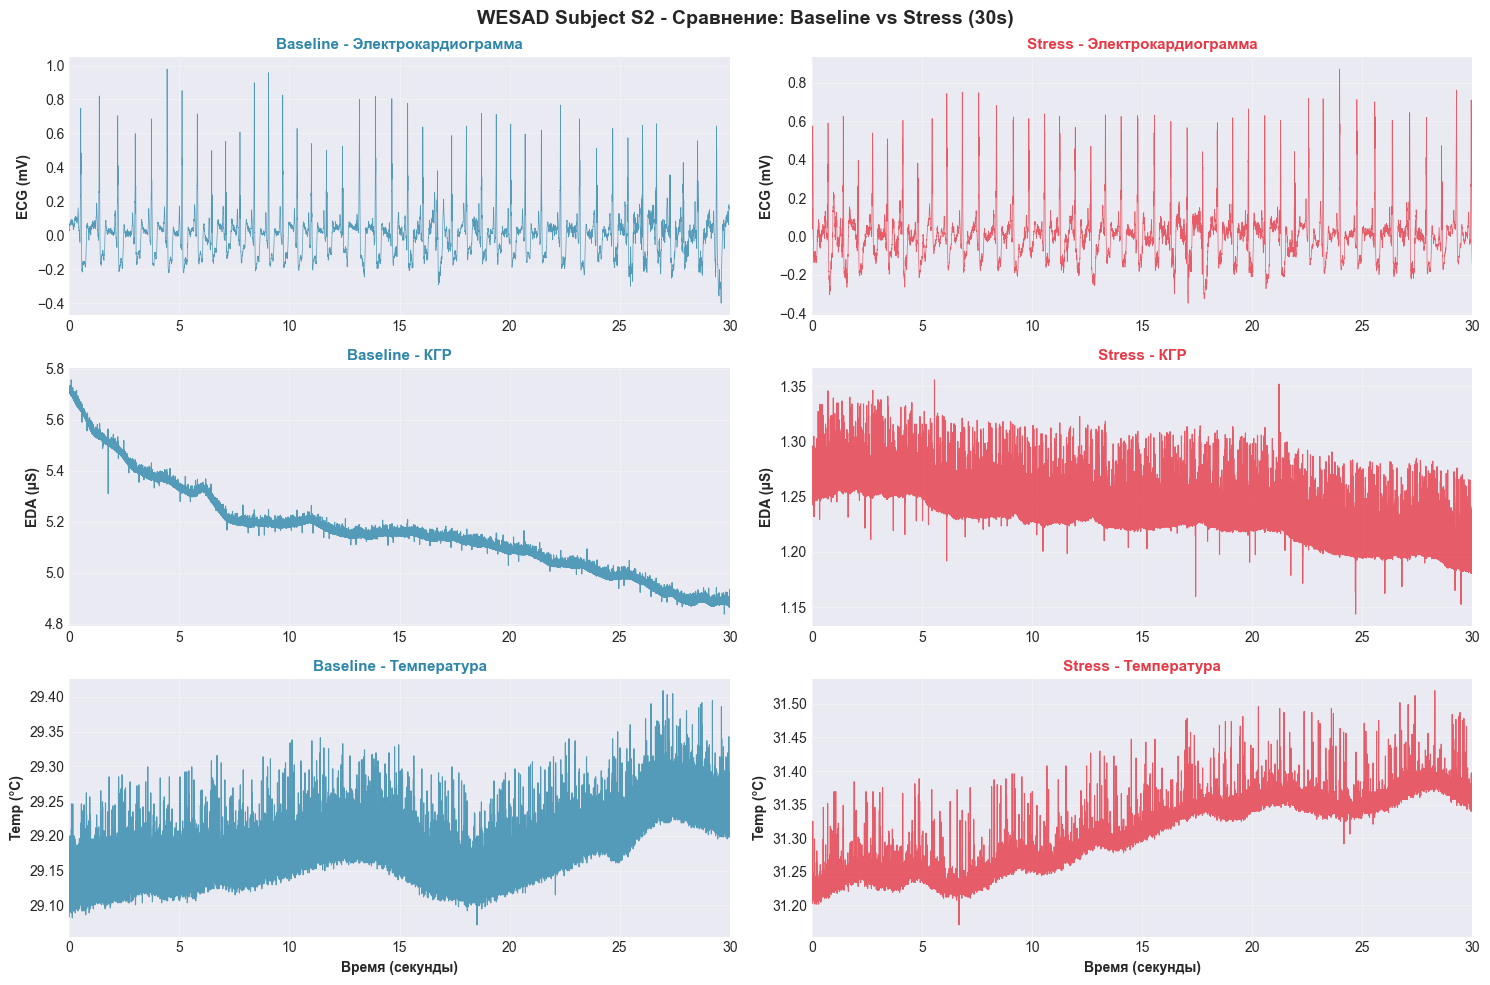

Сравнительная статистика: Baseline vs Stress
Сигнал     Состояние    Mean         Std          Min          Max         
----------------------------------------------------------------------
ECG        Baseline     0.0018       0.1314       -0.4014      0.9793      
ECG        Stress       0.0016       0.1295       -0.3471      0.8715      
ECG        Δ (Разница)  -0.0002      -0.0019     
----------------------------------------------------------------------
EDA        Baseline     5.1603       0.1806       4.8389       5.7568      
EDA        Stress       1.2372       0.0256       1.1436       1.3557      
EDA        Δ (Разница)  -3.9232      -0.1550     
----------------------------------------------------------------------
Temp       Baseline     29.1773      0.0452       29.0721      29.4089     
Temp       Stress       31.3066      0.0543       31.1708      31.5197     
Temp       Δ (Разница)  2.1293       0.0091      


In [15]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
def load_subject_data(subject_id):
    file_path = f'WESAD/S{subject_id}/S{subject_id}.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    return data

# Загрузка данных субъекта
subject_id = 2
data = load_subject_data(subject_id)

# Извлечение данных
chest = data['signal']['chest']
labels = data['label']

# Параметры
sampling_rate = 700  # Hz
duration_to_plot = 30  # секунд
samples_to_plot = sampling_rate * duration_to_plot

# Находим индексы для Baseline (1) и Stress (2)
baseline_indices = np.where(labels == 1)[0]
stress_indices = np.where(labels == 2)[0]

# Выбираем сегменты
baseline_start = baseline_indices[0]
baseline_end = baseline_start + samples_to_plot

stress_start = stress_indices[0]
stress_end = stress_start + samples_to_plot

# Временная ось
time_axis = np.arange(samples_to_plot) / sampling_rate

# Извлечение сигналов для Baseline
ecg_baseline = chest['ECG'][baseline_start:baseline_end].flatten()
eda_baseline = chest['EDA'][baseline_start:baseline_end].flatten()
temp_baseline = chest['Temp'][baseline_start:baseline_end].flatten()

# Извлечение сигналов для Stress
ecg_stress = chest['ECG'][stress_start:stress_end].flatten()
eda_stress = chest['EDA'][stress_start:stress_end].flatten()
temp_stress = chest['Temp'][stress_start:stress_end].flatten()

# Создание визуализации
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle(f'WESAD Subject S{subject_id} - Сравнение: Baseline vs Stress ({duration_to_plot}s)', 
             fontsize=14, fontweight='bold')

# ECG - Baseline
axes[0, 0].plot(time_axis, ecg_baseline, linewidth=0.5, color='#2E86AB', alpha=0.8)
axes[0, 0].set_ylabel('ECG (mV)', fontsize=10, fontweight='bold')
axes[0, 0].set_title('Baseline - Электрокардиограмма', fontsize=11, fontweight='bold', color='#2E86AB')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, duration_to_plot)

# ECG - Stress
axes[0, 1].plot(time_axis, ecg_stress, linewidth=0.5, color='#E63946', alpha=0.8)
axes[0, 1].set_ylabel('ECG (mV)', fontsize=10, fontweight='bold')
axes[0, 1].set_title('Stress - Электрокардиограмма', fontsize=11, fontweight='bold', color='#E63946')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, duration_to_plot)

# EDA - Baseline
axes[1, 0].plot(time_axis, eda_baseline, linewidth=0.8, color='#2E86AB', alpha=0.8)
axes[1, 0].set_ylabel('EDA (μS)', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Baseline - КГР', fontsize=11, fontweight='bold', color='#2E86AB')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, duration_to_plot)

# EDA - Stress
axes[1, 1].plot(time_axis, eda_stress, linewidth=0.8, color='#E63946', alpha=0.8)
axes[1, 1].set_ylabel('EDA (μS)', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Stress - КГР', fontsize=11, fontweight='bold', color='#E63946')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, duration_to_plot)

# Temperature - Baseline
axes[2, 0].plot(time_axis, temp_baseline, linewidth=0.8, color='#2E86AB', alpha=0.8)
axes[2, 0].set_ylabel('Temp (°C)', fontsize=10, fontweight='bold')
axes[2, 0].set_xlabel('Время (секунды)', fontsize=10, fontweight='bold')
axes[2, 0].set_title('Baseline - Температура', fontsize=11, fontweight='bold', color='#2E86AB')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(0, duration_to_plot)

# Temperature - Stress
axes[2, 1].plot(time_axis, temp_stress, linewidth=0.8, color='#E63946', alpha=0.8)
axes[2, 1].set_ylabel('Temp (°C)', fontsize=10, fontweight='bold')
axes[2, 1].set_xlabel('Время (секунды)', fontsize=10, fontweight='bold')
axes[2, 1].set_title('Stress - Температура', fontsize=11, fontweight='bold', color='#E63946')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlim(0, duration_to_plot)

plt.tight_layout()
plt.show()

# Сравнительная статистика
print("="*70)
print(f"Сравнительная статистика: Baseline vs Stress")
print("="*70)
print(f"{'Сигнал':<10} {'Состояние':<12} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-"*70)
print(f"{'ECG':<10} {'Baseline':<12} {ecg_baseline.mean():<12.4f} {ecg_baseline.std():<12.4f} {ecg_baseline.min():<12.4f} {ecg_baseline.max():<12.4f}")
print(f"{'ECG':<10} {'Stress':<12} {ecg_stress.mean():<12.4f} {ecg_stress.std():<12.4f} {ecg_stress.min():<12.4f} {ecg_stress.max():<12.4f}")
print(f"{'ECG':<10} {'Δ (Разница)':<12} {(ecg_stress.mean()-ecg_baseline.mean()):<12.4f} {(ecg_stress.std()-ecg_baseline.std()):<12.4f}")
print("-"*70)
print(f"{'EDA':<10} {'Baseline':<12} {eda_baseline.mean():<12.4f} {eda_baseline.std():<12.4f} {eda_baseline.min():<12.4f} {eda_baseline.max():<12.4f}")
print(f"{'EDA':<10} {'Stress':<12} {eda_stress.mean():<12.4f} {eda_stress.std():<12.4f} {eda_stress.min():<12.4f} {eda_stress.max():<12.4f}")
print(f"{'EDA':<10} {'Δ (Разница)':<12} {(eda_stress.mean()-eda_baseline.mean()):<12.4f} {(eda_stress.std()-eda_baseline.std()):<12.4f}")
print("-"*70)
print(f"{'Temp':<10} {'Baseline':<12} {temp_baseline.mean():<12.4f} {temp_baseline.std():<12.4f} {temp_baseline.min():<12.4f} {temp_baseline.max():<12.4f}")
print(f"{'Temp':<10} {'Stress':<12} {temp_stress.mean():<12.4f} {temp_stress.std():<12.4f} {temp_stress.min():<12.4f} {temp_stress.max():<12.4f}")
print(f"{'Temp':<10} {'Δ (Разница)':<12} {(temp_stress.mean()-temp_baseline.mean()):<12.4f} {(temp_stress.std()-temp_baseline.std()):<12.4f}")
print("="*70)